In [1]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:33249")
client

<Client: 'tcp://127.0.0.1:33249' processes=9 threads=72, memory=136.41 GiB>

In [2]:
import xarray as xr
import numpy as np
import os.path as op
import tripyview as tpv
from xgcm.grid import Grid
import gsw
import matplotlib.pyplot as plt

# xr.set_options(keep_attrs=True)
# do_parallel       = True
# parallel_nprc     = 16   # number of dask workers
# parallel_nprc_bin = 8   # number of processor used to parallize the binning loop
# parallel_tmem     = 256   # max. available RAM

%matplotlib inline

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:8: UserWarning: The seawater library is deprecated! Please use gsw instead.
  import seawater as sw


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages


In [3]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
ddir = "/work/uo0119/a270067/runtime/awicm3-v3.1/"
sdir = "/scratch/b/b383315/fesom2/next/"
wdir = "/work/ba1254/b383315/fesom2/next/"

In [5]:
plt_contb = False        # background contour line (thin)
plt_contf = False       # contour line of main colorbar steps 
plt_contr = False       # contour line of reference value 
plt_contl = False       # label contourline of main colorbar steps 
do_plt = 'tpc'          # plot pcolor (tpc) or contourf (tcf)
box = [-180, 180, -90, 90] # regional limitation of plot. [lonmin, lonmax, latmin, latmax]
proj = 'rob'               # Robinson projection
# proj = 'sps'               # SouthPolarStereo projection
do_rescale = None          # rescale data: None, 'log10', 'slog10', np.array(...)
nrow0 = 1                  # int, (default: 1) number of columns when plotting multiple data panels
ncol0 = 1                  # int, (default: 1) number of rows when plotting multiple data panels
do_enum = False            # bool, (default: False) do enumeration of axes with a), b), c) …
cbl_opt = dict()           # dict, (default: dict()) direct option for colorbar labels (fontsize, fontweight, …) via kwarg
cbtl_opt = dict()          # dict, (default: dict()) direct option for colorbar tick labels (fontsize, fontweight, …) via kwarg
save_dpi = 500

# cstr      = 'matplotlib.RdBu_r'
# cnum      = 30
# cref      = 0
crange    = None
cfac      = None
climit    = None
chist     = True
ctresh    = 0.995

# cb_label = "DS05 - clim salt annual"
cstr      = 'matplotlib.RdBu_r'
# cstr      = 'cmocean.balance'
cnum      = 41
cref      = 0.
cmin      = -1e-6
cmax      = 1e-6

cinfo = tpv.set_cinfo(cstr, cnum, crange, cmin, cmax, 
                      cref, cfac, climit, chist, ctresh
                     ) 

In [6]:
NXX = 50
ds1 = xr.open_dataset(op.join(ddir,"N%2d/outdata/fesom/unod.fesom.2090.nc"
                              % NXX),
                     chunks={"nz1":1,"x":100000}
                    )
ds = xr.open_dataset(op.join(ddir,"N%2d/outdata/fesom/w.fesom.2090.nc"
                             % NXX),
                     chunks={"nz":1,"x":100000}
                    )
dssalt = xr.open_dataset(op.join(ddir,"N%2d/outdata/fesom/salt.fesom.2090.nc"
                              % NXX),
                     chunks={"nz1":1,"x":100000}
                    ).rename_dims({'x':'nod2'})
ds1, ds

(<xarray.Dataset> Size: 29GB
 Dimensions:  (time: 12, nz1: 47, x: 12952215)
 Coordinates:
   * time     (time) datetime64[ns] 96B 2090-01-31T23:57:00 ... 2090-12-31T23:...
   * nz1      (nz1) float64 376B 2.5 7.5 15.0 ... 5.525e+03 5.825e+03 6.125e+03
 Dimensions without coordinates: x
 Data variables:
     unod     (time, nz1, x) float32 29GB dask.array<chunksize=(1, 1, 100000), meta=np.ndarray>
 Attributes: (12/21)
     CDI:                                 Climate Data Interface version 2.2.4...
     Conventions:                         CF-1.6
     FESOM_model:                         FESOM2
     FESOM_website:                       fesom.de
     FESOM_git_SHA:                       e23bc823
     FESOM_MeshPath:                      /work/ab0995/a270067/fesom2/next/mesh/
     ...                                  ...
     FESOM_evp_rheol_steps:               120
     FESOM_opt_visc:                      7
     FESOM_use_wsplit:                    -1
     FESOM_autorotate_back_to_geo: 

In [7]:
iz2000 = 31
iz4300 = 40
dz = xr.DataArray(np.diff(ds.nz), dims=["nz1"],
                  coords={"nz1":ds1.nz1}
                 ).isel(nz1=slice(None,iz4300))
dz

<xarray.DataArray (nz1: 40)> Size: 320B
array([  5.,   5.,  10.,  10.,  10.,  10.,  10.,  10.,  10.,  10.,  10.,
        15.,  20.,  25.,  30.,  40.,  50.,  60.,  70.,  80.,  90., 100.,
       110., 120., 130., 140., 150., 170., 200., 220., 230., 250., 250.,
       250., 250., 250., 250., 250., 250., 250.])
Coordinates:
  * nz1      (nz1) float64 320B 2.5 7.5 15.0 ... 3.775e+03 4.025e+03 4.275e+03

In [8]:
dt = 180. # 3 minutes

mesh_path = '/work/ab0995/a270067/fesom2/next/mesh/'
mesh = tpv.load_mesh_fesom2(mesh_path, do_rot='None', focus=0, 
                            do_info=True, do_pickle=False
                           )
mesh

 > load mesh from *.out files: /work/ab0995/a270067/fesom2/next/mesh
 > load e_area from fesom.mesh.diag.nc
 > load n_area from fesom.mesh.diag.nc
 > compute lsmask
 > save *.shp to /home/b/b383315/meshcache_tripyview/mesh/tripyview_fesom2_mesh_pbnd.shp
 > augment lsmask
 > save *.shp to /home/b/b383315/meshcache_tripyview/mesh/tripyview_fesom2_mesh_focus=0.shp
___FESOM2 MESH INFO________________________
 > path            = /work/ab0995/a270067/fesom2/next/mesh
 > id              = mesh
 > do rot          = None
 > [al,be,ga]      = 50, 15, -90
 > do augmpbnd     = True
 > do cavity       = False
 > do lsmask       = True
 > do earea,eresol = True, False
 > do narea,nresol = True, False
___________________________________________
 > #node           = 12952215
 > #elem           = 25742475
 > #lvls           = 48
___________________________________________


___FESOM2 MESH INFO________________________
 > path            = /work/ab0995/a270067/fesom2/next/mesh
 > id              = mesh
 > do rot          = None
 > [al,be,ga]      = 50, 15, -90
 > do augmpbnd     = True
 > do cavity       = False
 > do lsmask       = True
 > do earea,eresol = True, False
 > do narea,nresol = True, False
___________________________________________
 > #node           = 12952215
 > #elem           = 25742475
 > #lvls           = 48
___________________________________________

In [9]:
diag = xr.open_dataset(op.join(mesh_path, 'fesom.mesh.diag.nc'),
                       chunks={'nz':1,"nz1":1,'elem':200000,
                               'nod2':100000,'edg_n':300000}
                      )

ddx = diag['gradient_sca_x']
ddy = diag['gradient_sca_y']
area = xr.DataArray(.5*(diag.nod_area.isel(nz=slice(None,-1)).data
                        + diag.nod_area.isel(nz=slice(1,None)).data
                       ),
                    dims=dssalt.salt.isel(time=0).dims, 
                    coords=dssalt.salt.isel(time=0).coords
                   ).chunk(dssalt.salt.isel(time=0).chunks
                          ).isel(nz1=slice(None,iz4300))
depth = diag.zbar_n_bottom.load()
depth.coords["nod2"] = ("nod2",np.arange(len(diag.nod2)))
area.coords["nod2"] = ("nod2",np.arange(len(diag.nod2)))

diag

<xarray.Dataset> Size: 10GB
Dimensions:            (nz: 48, nz1: 47, elem: 25742475, nod2: 12952215, n3: 3,
                        n2: 2, N: 8, edg_n: 38695599, n4: 4)
Coordinates:
  * nz                 (nz) float64 384B 0.0 -5.0 -10.0 ... -6e+03 -6.25e+03
  * nz1                (nz1) float64 376B -2.5 -7.5 ... -5.825e+03 -6.125e+03
Dimensions without coordinates: elem, nod2, n3, n2, N, edg_n, n4
Data variables: (12/19)
    elem_area          (elem) float64 206MB dask.array<chunksize=(200000,), meta=np.ndarray>
    nlevels_nod2D      (nod2) int32 52MB dask.array<chunksize=(100000,), meta=np.ndarray>
    nlevels            (elem) int32 103MB dask.array<chunksize=(200000,), meta=np.ndarray>
    nod_in_elem2D_num  (nod2) int32 52MB dask.array<chunksize=(100000,), meta=np.ndarray>
    nod_part           (nod2) int32 52MB dask.array<chunksize=(100000,), meta=np.ndarray>
    elem_part          (elem) int32 103MB dask.array<chunksize=(200000,), meta=np.ndarray>
    ...                 ...
    nod_in_elem2D      (N, nod2) int32 414MB dask.array<chunksize=(8, 100000), meta=np.ndarray>
    edges              (n2, edg_n) int32 310MB dask.array<chunksize=(2, 300000), meta=np.ndarray>
    edge_tri           (n2, edg_n) int32 310MB dask.array<chunksize=(2, 300000), meta=np.ndarray>
    edge_cross_dxdy    (n4, edg_n) float64 1GB dask.array<chunksize=(4, 300000), meta=np.ndarray>
    gradient_sca_x     (elem, n3) float64 618MB dask.array<chunksize=(200000, 3), meta=np.ndarray>
    gradient_sca_y     (elem, n3) float64 618MB dask.array<chunksize=(200000, 3), meta=np.ndarray>

# Advection of $u$
## Saving 3D to scratch

In [10]:
ystart = 2098
NXX = 50

JFMJAS = np.concatenate((np.arange(1,4, dtype=int),
                         np.arange(7,10, dtype=int))
                       )

# for yy in np.arange(ystart,2011,1, dtype=int):
for yy in range(ystart,2101):
    
    u_path = op.join(ddir,'N%02d/outdata/fesom/unod.fesom.%4d.nc'
                      % (NXX,yy))
    Au_path = op.join(ddir,'N%02d/outdata/fesom/ke_adv_u.fesom.%4d.nc'
                      % (NXX,yy))
        
    if yy == ystart:
        months = JFMJAS[-3:]
        print(months)
    else:
        months = JFMJAS
    
    for mm in months:
        
        if op.exists(op.join(sdir,"ke_adv/N%2d/Tu_%4d-%02d.zarr/zarr.json" 
                             % (NXX,yy,mm))):
            pass
        else:
            divVbub = xr.open_zarr(op.join(sdir,"ke_adv/divVbub_%4d-%02d.zarr" 
                                           % (yy,mm))
                                  )

            for iz in range(iz4300):
                if iz == 0:
                    unod = tpv.load_data_fesom2(mesh, u_path, do_filename=True,
                                              vname="unod", do_info=False,
                                              depth=[ds1.nz1[iz].values], year=yy, mon=[mm]
                                             ).chunk({'nod2':100000})
                    Aunod = tpv.load_data_fesom2(mesh, Au_path, do_filename=True,
                                          vname="ke_adv_u", do_info=False,
                                          depth=[ds1.nz1[iz].values], year=yy, mon=[mm]
                                         ).chunk({'nod2':100000})
                else:
                    unod = xr.concat([unod, 
                                      tpv.load_data_fesom2(mesh, u_path, do_filename=True,
                                              vname="unod", do_info=False,
                                              depth=[ds1.nz1[iz].values], year=yy, mon=[mm]
                                             ).chunk({'nod2':100000})
                                     ], "nz1")
                    Aunod = xr.concat([Aunod, 
                                       tpv.load_data_fesom2(mesh, Au_path, do_filename=True,
                                          vname="ke_adv_u", do_info=False,
                                          depth=[ds1.nz1[iz].values], year=yy, mon=[mm]
                                         ).chunk({'nod2':100000})
                                     ], "nz1")

            tu = (unod.unod
                  * (-Aunod.n_ke_adv_u/dt - divVbub.divVu)
                 )

            dsave = tu.to_dataset(name="Tu")
            dsave.to_zarr(op.join(sdir,"ke_adv/N%2d/Tu_%4d-%02d.zarr" 
                                  % (NXX,yy,mm)),
                          mode='w')
            dsave.close(), divVbub.close()
            unod.close(), Aunod.close()
            print("iiiiiiiiiiiiiiiiiiii")
            print("iiSaved to scratch!!")
            print("!!!!!!!!!!!!!!!!!!!!")
            print("Month: ", mm)

            del tu
    print("Year: ", yy)

[7 8 9]


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 98.20 MiB.
This may cause some slowdown.
Consider loadin

 > do interpolation e2n


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyvi

 > do interpolation e2n


...

 > do interpolation e2n


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyvi

 > do interpolation e2n


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 3.87 GiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aw

iiiiiiiiiiiiiiiiiiii
iiSaved to scratch!!
!!!!!!!!!!!!!!!!!!!!
Month:  7
Year:  2098
Year:  2099
Year:  2100


## Saving 2D to work

[7 8 9]


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distrib

iiiiiiiiiiiiiiiii
iiSaved to work!!
!!!!!!!!!!!!!!!!!
Month:  7


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distrib

iiiiiiiiiiiiiiiii
iiSaved to work!!
!!!!!!!!!!!!!!!!!
Month:  8


...

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distrib

<xarray.Dataset> Size: 104MB
Dimensions:  (nod2: 12952215)
Dimensions without coordinates: nod2
Data variables:
    Tu       (nod2) float64 104MB dask.array<chunksize=(100000,), meta=np.ndarray>


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 53.67 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


{'cstr': 'matplotlib.RdBu_r', 'cnum': 41, 'cmin': -1e-06, 'cmax': 1e-06, 'cref': np.float64(0.0), 'chist': True, 'ctresh': 0.995, 'cnlab': 8, 'cmap': <matplotlib.colors.ListedColormap object at 0x7ffc21956630>, 'clevel': array([-1.00e-06, -9.75e-07, -9.50e-07, -9.25e-07, -9.00e-07, -8.75e-07,
       -8.50e-07, -8.25e-07, -8.00e-07, -7.75e-07, -7.50e-07, -7.25e-07,
       -7.00e-07, -6.75e-07, -6.50e-07, -6.25e-07, -6.00e-07, -5.75e-07,
       -5.50e-07, -5.25e-07, -5.00e-07, -4.75e-07, -4.50e-07, -4.25e-07,
       -4.00e-07, -3.75e-07, -3.50e-07, -3.25e-07, -3.00e-07, -2.75e-07,
       -2.50e-07, -2.25e-07, -2.00e-07, -1.75e-07, -1.50e-07, -1.25e-07,
       -1.00e-07, -7.50e-08, -5.00e-08, -2.50e-08,  0.00e+00,  2.50e-08,
        5.00e-08,  7.50e-08,  1.00e-07,  1.25e-07,  1.50e-07,  1.75e-07,
        2.00e-07,  2.25e-07,  2.50e-07,  2.75e-07,  3.00e-07,  3.25e-07,
        3.50e-07,  3.75e-07,  4.00e-07,  4.25e-07,  4.50e-07,  4.75e-07,
        5.00e-07,  5.25e-07,  5.50e-07,  5.75e-07

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


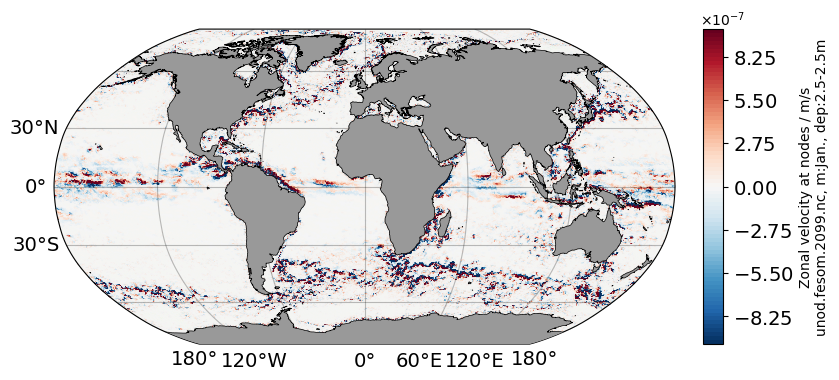

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/api/asynchronous.py:203: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


iiiiiiiiiiiiiiiii
iiSaved to work!!
!!!!!!!!!!!!!!!!!
Month:  1


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distrib

iiiiiiiiiiiiiiiii
iiSaved to work!!
!!!!!!!!!!!!!!!!!
Month:  2


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distrib

...

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distrib

<xarray.Dataset> Size: 104MB
Dimensions:  (nod2: 12952215)
Dimensions without coordinates: nod2
Data variables:
    Tu       (nod2) float64 104MB dask.array<chunksize=(100000,), meta=np.ndarray>


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 53.67 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


{'cstr': 'matplotlib.RdBu_r', 'cnum': 41, 'cmin': -1e-06, 'cmax': 1e-06, 'cref': np.float64(0.0), 'chist': True, 'ctresh': 0.995, 'cnlab': 8, 'cmap': <matplotlib.colors.ListedColormap object at 0x7ffd21978ef0>, 'clevel': array([-1.00e-06, -9.75e-07, -9.50e-07, -9.25e-07, -9.00e-07, -8.75e-07,
       -8.50e-07, -8.25e-07, -8.00e-07, -7.75e-07, -7.50e-07, -7.25e-07,
       -7.00e-07, -6.75e-07, -6.50e-07, -6.25e-07, -6.00e-07, -5.75e-07,
       -5.50e-07, -5.25e-07, -5.00e-07, -4.75e-07, -4.50e-07, -4.25e-07,
       -4.00e-07, -3.75e-07, -3.50e-07, -3.25e-07, -3.00e-07, -2.75e-07,
       -2.50e-07, -2.25e-07, -2.00e-07, -1.75e-07, -1.50e-07, -1.25e-07,
       -1.00e-07, -7.50e-08, -5.00e-08, -2.50e-08,  0.00e+00,  2.50e-08,
        5.00e-08,  7.50e-08,  1.00e-07,  1.25e-07,  1.50e-07,  1.75e-07,
        2.00e-07,  2.25e-07,  2.50e-07,  2.75e-07,  3.00e-07,  3.25e-07,
        3.50e-07,  3.75e-07,  4.00e-07,  4.25e-07,  4.50e-07,  4.75e-07,
        5.00e-07,  5.25e-07,  5.50e-07,  5.75e-07

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


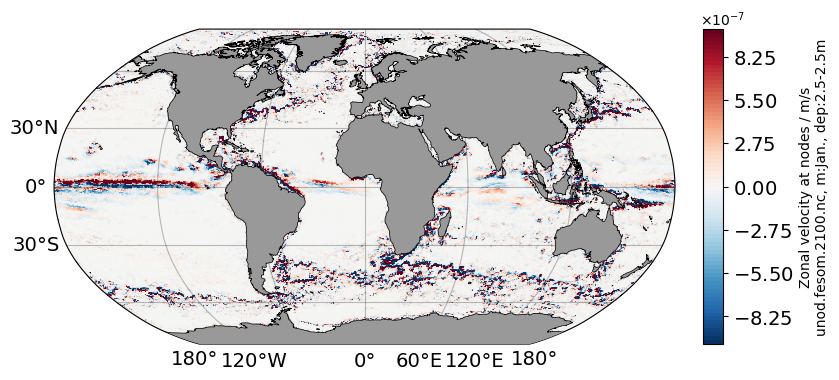

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/api/asynchronous.py:203: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


iiiiiiiiiiiiiiiii
iiSaved to work!!
!!!!!!!!!!!!!!!!!
Month:  1


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter

iiiiiiiiiiiiiiiii
iiSaved to work!!
!!!!!!!!!!!!!!!!!
Month:  2


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distrib

...

iiiiiiiiiiiiiiiii
iiSaved to work!!
!!!!!!!!!!!!!!!!!
Month:  7


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distrib

iiiiiiiiiiiiiiiii
iiSaved to work!!
!!!!!!!!!!!!!!!!!
Month:  8


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distrib

iiiiiiiiiiiiiiiii
iiSaved to work!!
!!!!!!!!!!!!!!!!!
Month:  9
Year:  2100


In [11]:
ystart = 2098
NXX = 50

JFMJAS = np.concatenate((np.arange(1,4, dtype=int),
                         np.arange(7,10, dtype=int)))

for yy in range(ystart,2101):
    
    h_path = op.join(ddir,'N%02d/outdata/fesom/MLD3.fesom.%4d.nc'
                      % (NXX,yy))
        
    if yy == ystart:
        months = JFMJAS[-3:]
        print(months)
    else:
        months = JFMJAS
    
    for mm in months:
        
        tu = xr.open_zarr(op.join(sdir,"ke_adv/N%2d/Tu_%4d-%02d.zarr" 
                              % (NXX,yy,mm))
                              )
        
        mld = tpv.load_data_fesom2(mesh, h_path, do_filename=True,
                                  vname="MLD3", do_info=False,
                                  year=yy, mon=[mm]
                                 ).chunk({'nod2':100000})

        dsave = ((tu.Tu
                  * dz
                 ).where(tu.Tu.nz1<np.abs(mld.MLD3)).sum("nz1",skipna=True) 
                 / np.abs(mld.MLD3)
                ).reset_coords(drop=True).to_dataset(name="Tu")
        if mm == 1:
            print(dsave)
            hfig, hax, hcb = tpv.plot_hslice(
                mesh, 
                data=dsave.load(), 
                cinfo=cinfo, 
                box=box, nrow=1, ncol=1, 
                proj=proj, do_rescale=do_rescale,  
                do_plt=do_plt, plt_contb=plt_contb, plt_contf=plt_contf, 
                plt_contr=plt_contr, plt_contl=plt_contl, 
                do_enum=do_enum, 
                axl_opt=dict({'fontsize':10, 'pad': 15}),
                ax_opt=dict({'fig_sizefac':2., 'cb_plt':True, 
                             'cb_plt_single':True, 'cb_pos':'vertical'}),
                cbl_opt=dict({'fontsize':10}), cb_label=None, 
                cbtl_opt=dict(),
                # do_save=save_path, 
                # save_dpi=save_dpi
            ) 
            plt.show()
        dsave.to_zarr(op.join(wdir,"ke_adv/N%2d/MLD3/TuH_%4d-%02d.zarr" 
                              % (NXX,yy,mm)),
                      mode='w')
        dsave.close()
        tu.close(), mld.close()
        print("iiiiiiiiiiiiiiiii")
        print("iiSaved to work!!")
        print("!!!!!!!!!!!!!!!!!")
        
        print("Month: ", mm)
    print("Year: ", yy)

In [10]:
incre = 0.
regions = dict(GulfStrEx = {"we":-70-incre, "ea":-55+incre, "so":32-incre, "no":42+incre},
               KuroEx    = {"we":142-incre, "ea":157+incre, "so":32-incre, "no":42+incre},
               DrakePass = {"we":-58-incre, "ea":-38+incre, "so":-61-incre,"no":-46+incre},
               Agulhas   = {"we":10-incre, "ea":25+incre, "so":-45-incre, "no":-35+incre},
               WestPac   = {"we":130-incre, "ea":145+incre, "so":10-incre, "no":25+incre},
               EqAtl     = {"we":-30-incre, "ea":-15+incre, "so":-10-incre, "no":10+incre},
               EastPac   = {"we":-145-incre, "ea":-130+incre, "so":35-incre, "no":50+incre}
              )

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 556.20 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warn

<xarray.DataArray (nz1: 40)> Size: 320B
array([-4.22214765e-09, -4.46711943e-09, -4.53370466e-09, -4.53562353e-09,
       -3.64189639e-09, -3.24379263e-10,  4.45158605e-09,  6.68449658e-09,
        4.96354207e-09,  2.87992782e-09,  2.14040966e-09,  1.28669362e-09,
        1.04805043e-09,  6.59892784e-10,  2.16853846e-10, -8.30248336e-11,
       -5.31977051e-11, -4.68406983e-12, -5.48088482e-11, -6.73725600e-11,
       -2.57150051e-11,  1.15388688e-11,  4.00147671e-11,  5.97807920e-11,
        6.82281632e-11,  7.24030972e-11,  6.73481312e-11,  5.30267411e-11,
        3.71416665e-11,  2.38479018e-11,  1.25413451e-11,  3.98976590e-12,
        1.05859598e-11,  7.58832454e-12, -1.44562902e-11, -1.42089177e-10,
       -4.16956763e-10, -9.64069191e-10, -1.93443703e-09, -2.74679275e-09])
Coordinates:
  * nz1      (nz1) float64 320B 2.5 7.5 15.0 ... 3.775e+03 4.025e+03 4.275e+03
Attributes: (12/22)
    long_name:    zonal velocity at nodes
    units:        m/s
    description:  zonal velocity 

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distrib

<xarray.DataArray (nz1: 40)> Size: 320B
array([-3.93621686e-09, -4.04972930e-09, -3.88252473e-09, -3.56836932e-09,
       -3.20524104e-09, -1.58964951e-09,  1.50372477e-09,  4.38280305e-09,
        4.35437775e-09,  2.82486257e-09,  2.26459784e-09,  1.06541253e-09,
        9.14133727e-10,  8.94167870e-10,  8.05305166e-10,  6.41251590e-10,
        5.35762494e-10,  3.71023290e-10,  1.75311800e-10,  4.29906947e-11,
       -3.17797947e-11, -3.09295891e-11,  1.85108935e-11,  5.95885072e-11,
        8.01528489e-11,  8.31820982e-11,  7.14267324e-11,  5.75432131e-11,
        4.81547791e-11,  4.28659056e-11,  3.63992491e-11,  2.30994646e-11,
        2.14742068e-11,  8.27765853e-12, -1.39154463e-11, -9.33755384e-11,
       -2.14533873e-10, -5.91162811e-10, -9.90730800e-10, -1.52852463e-09])
Coordinates:
  * nz1      (nz1) float64 320B 2.5 7.5 15.0 ... 3.775e+03 4.025e+03 4.275e+03
Attributes: (12/22)
    long_name:    zonal velocity at nodes
    units:        m/s
    description:  zonal velocity 

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distrib

...

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distrib

<xarray.DataArray (nz1: 40)> Size: 320B
array([-2.48928918e-09, -2.38315620e-09, -8.75835090e-10,  2.60276379e-09,
        3.83583074e-09,  3.03666558e-09,  2.61870460e-09,  2.63414234e-09,
        2.62008239e-09,  2.40526138e-09,  2.22992965e-09,  1.73352196e-09,
        1.30166576e-09,  9.42033817e-10,  6.48575214e-10,  4.01755702e-10,
        2.32821925e-10,  9.71666170e-11, -2.81668203e-11, -1.06817501e-10,
       -1.10017929e-10, -7.29247074e-11, -2.87188338e-11,  5.96391130e-12,
        1.99348848e-11,  1.71789779e-11,  7.32825613e-12,  1.29213256e-12,
        4.24541508e-12,  9.65258162e-12,  1.36854815e-11,  5.70716182e-12,
       -3.03223419e-12, -3.44201026e-12, -5.59474728e-12, -1.53890516e-11,
       -2.61018154e-11, -3.83136186e-11, -3.88848728e-11, -4.17373524e-11])
Coordinates:
  * nz1      (nz1) float64 320B 2.5 7.5 15.0 ... 3.775e+03 4.025e+03 4.275e+03
Attributes: (12/22)
    long_name:    zonal velocity at nodes
    units:        m/s
    description:  zonal velocity 

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distrib

<xarray.DataArray (nz1: 40)> Size: 320B
array([ 3.24289541e-09,  2.93776544e-09,  2.15544813e-09,  1.64557966e-09,
        3.72744540e-09,  5.36810917e-09,  4.08366002e-09,  3.23410079e-09,
        3.03030446e-09,  2.93624716e-09,  2.93805850e-09,  2.40400995e-09,
        1.91866196e-09,  1.43486570e-09,  9.79829617e-10,  5.25403611e-10,
        2.73204616e-10,  1.73978168e-10,  1.03389945e-10,  6.65252886e-11,
        6.24947541e-11,  7.29194830e-11,  6.44884942e-11,  5.53883507e-11,
        4.16889962e-11,  2.35516681e-11,  8.64687458e-12,  1.72356278e-12,
        2.29111298e-12,  2.23915314e-12,  2.16753851e-12, -4.21816118e-12,
       -1.13806896e-11, -1.76988284e-11, -3.08573155e-11, -5.05213499e-11,
       -5.66318327e-11, -6.90979047e-11, -5.36352633e-11, -3.69740077e-11])
Coordinates:
  * nz1      (nz1) float64 320B 2.5 7.5 15.0 ... 3.775e+03 4.025e+03 4.275e+03
Attributes: (12/22)
    long_name:    zonal velocity at nodes
    units:        m/s
    description:  zonal velocity 

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distrib

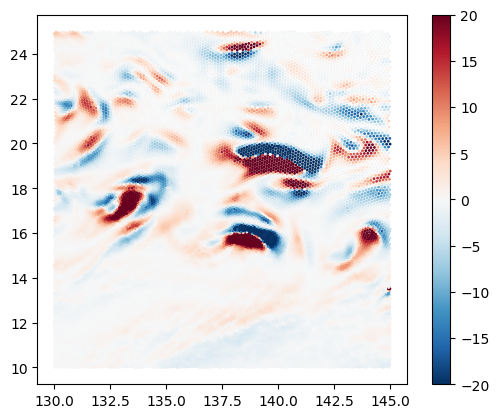

<xarray.DataArray (nz1: 40)> Size: 320B
array([ 1.40729135e-09,  1.24198390e-09,  1.21455678e-10,  2.73613448e-10,
        5.13589938e-09,  9.28050689e-09,  6.33336582e-09,  3.36088828e-09,
        2.84886260e-09,  2.94649430e-09,  3.17068629e-09,  2.83138797e-09,
        2.45049023e-09,  1.84463436e-09,  1.22325686e-09,  6.97613766e-10,
        4.29701069e-10,  2.97489291e-10,  1.40637321e-10,  2.10335694e-11,
       -7.04009890e-11, -7.49045159e-11, -3.24035597e-11, -4.72573218e-14,
        9.91080893e-12,  6.33293701e-12,  1.87234477e-12, -1.05577355e-12,
       -3.47908598e-12, -5.10603097e-12, -7.79973376e-12, -1.36962449e-11,
       -2.27173540e-11, -2.58507436e-11, -3.94624424e-11, -6.08311116e-11,
       -9.69073256e-11, -1.45258286e-10, -1.81676179e-10, -1.99911708e-10])
Coordinates:
  * nz1      (nz1) float64 320B 2.5 7.5 15.0 ... 3.775e+03 4.025e+03 4.275e+03
Attributes: (12/22)
    long_name:    zonal velocity at nodes
    units:        m/s
    description:  zonal velocity 

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


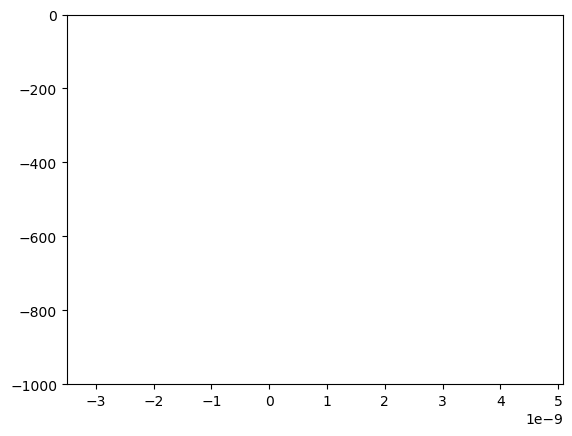

Year:  2090


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/api/asynchronous.py:203: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/

<xarray.DataArray (nz1: 40)> Size: 320B
array([-3.12644649e-09, -3.18285220e-09, -3.11479935e-09, -2.78518251e-09,
       -7.27365546e-10,  3.24166341e-09,  4.77703742e-09,  3.50154367e-09,
        2.05556846e-09,  1.42911608e-09,  1.45201096e-09,  1.03625484e-09,
        7.94588758e-10,  4.84181123e-10,  2.12718647e-10,  1.33050422e-11,
        4.35044318e-12,  1.80161433e-11, -2.49933436e-11, -9.05946593e-11,
       -1.27955681e-10, -9.30670894e-11, -4.19074448e-11, -1.44037831e-12,
        1.89822078e-11,  2.37609947e-11,  1.77519501e-11,  9.09537368e-12,
       -1.37236839e-12, -9.87956502e-12, -1.85149399e-11, -3.25981103e-11,
       -5.45309284e-11, -1.02524561e-10, -1.70708476e-10, -3.17408920e-10,
       -6.98616132e-10, -1.54528163e-09, -2.72392940e-09, -3.26398314e-09])
Coordinates:
  * nz1      (nz1) float64 320B 2.5 7.5 15.0 ... 3.775e+03 4.025e+03 4.275e+03
Attributes: (12/22)
    long_name:    zonal velocity at nodes
    units:        m/s
    description:  zonal velocity 

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distrib

<xarray.DataArray (nz1: 40)> Size: 320B
array([-3.85396467e-09, -3.74455619e-09, -3.37636531e-09, -3.00525436e-09,
       -2.16516604e-09, -5.38140572e-10,  1.43079135e-09,  2.14277502e-09,
        1.61217162e-09,  1.11783544e-09,  1.13409040e-09,  7.52452365e-10,
        5.26866725e-10,  3.45033699e-10,  1.43313749e-10,  1.58507754e-11,
        7.18308004e-11,  1.26548271e-10,  1.05007349e-10,  5.43013687e-11,
        1.23879450e-11,  1.08631861e-11,  1.71107176e-11,  2.69182638e-11,
        3.36484333e-11,  2.99337479e-11,  2.00788271e-11,  9.71929860e-12,
        1.77525796e-12, -2.89407839e-12, -9.00090548e-12, -1.86221563e-11,
       -2.86503943e-11, -3.42039366e-11, -4.61375998e-11, -1.34125312e-10,
       -3.95106824e-10, -1.02094819e-09, -1.87738612e-09, -2.74945406e-09])
Coordinates:
  * nz1      (nz1) float64 320B 2.5 7.5 15.0 ... 3.775e+03 4.025e+03 4.275e+03
Attributes: (12/22)
    long_name:    zonal velocity at nodes
    units:        m/s
    description:  zonal velocity 

...

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distrib

<xarray.DataArray (nz1: 40)> Size: 320B
array([-3.79562178e-09, -3.39225326e-09, -2.76609327e-09, -7.72228020e-10,
        7.17835852e-11, -5.05686837e-10, -1.12439455e-09, -1.26446535e-09,
       -1.07437599e-09, -8.18043014e-10, -4.95380092e-10, -3.50114895e-10,
       -2.25848526e-10, -3.70199671e-11,  1.39688803e-10,  2.67135116e-10,
        3.20838200e-10,  2.61284558e-10,  1.41593233e-10,  4.88538565e-11,
        5.29520620e-12, -1.32637328e-11, -2.72757480e-11, -3.04808325e-11,
       -3.11390286e-11, -2.64657681e-11, -1.56207405e-11, -1.29460079e-11,
       -2.21149865e-12, -2.00124973e-12, -4.90145283e-13, -1.96445769e-13,
        5.51217586e-13,  8.92199944e-13,  5.63180406e-13,  3.52796327e-12,
        3.41779782e-12,  2.87023023e-12, -7.46077859e-13, -1.50695008e-12])
Coordinates:
  * nz1      (nz1) float64 320B 2.5 7.5 15.0 ... 3.775e+03 4.025e+03 4.275e+03
Attributes: (12/22)
    long_name:    zonal velocity at nodes
    units:        m/s
    description:  zonal velocity 

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distrib

<xarray.DataArray (nz1: 40)> Size: 320B
array([ 1.81097790e-09,  2.03740575e-09,  2.47336262e-09,  4.54446502e-09,
        5.93518659e-09,  6.04809551e-09,  6.26289927e-09,  6.44175859e-09,
        6.39358026e-09,  5.93952640e-09,  5.33859598e-09,  4.40688397e-09,
        3.34277067e-09,  2.46639015e-09,  1.69536302e-09,  1.10114266e-09,
        7.34042732e-10,  4.91211929e-10,  3.36592405e-10,  2.75128969e-10,
        2.51348891e-10,  2.11603199e-10,  1.50763522e-10,  9.88285852e-11,
        5.07163466e-11,  2.47565584e-11,  9.11195370e-12, -8.92908950e-13,
        2.43414676e-12,  1.73476218e-12, -4.13643656e-12, -1.03634230e-11,
       -1.84279521e-11, -2.56020232e-11, -3.67425137e-11, -6.16325191e-11,
       -9.46985826e-11, -1.68852433e-10, -3.14325644e-10, -3.61493284e-10])
Coordinates:
  * nz1      (nz1) float64 320B 2.5 7.5 15.0 ... 3.775e+03 4.025e+03 4.275e+03
Attributes: (12/22)
    long_name:    zonal velocity at nodes
    units:        m/s
    description:  zonal velocity 

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distrib

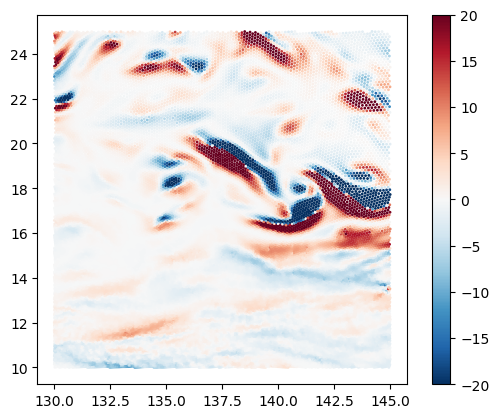

<xarray.DataArray (nz1: 40)> Size: 320B
array([ 2.26324821e-10,  1.69356565e-09,  2.35877699e-09,  4.14547426e-09,
        6.29376186e-09,  6.05932954e-09,  5.59771417e-09,  5.57147198e-09,
        5.58596164e-09,  5.40097172e-09,  5.08150096e-09,  4.32670477e-09,
        3.45630474e-09,  2.49924197e-09,  1.68443276e-09,  1.01351589e-09,
        5.86710503e-10,  2.81378801e-10,  1.01222106e-11, -1.89758941e-10,
       -3.00979435e-10, -3.05069037e-10, -2.25497165e-10, -1.20243604e-10,
       -5.84727548e-11, -2.22861927e-11, -8.95274252e-12, -7.01111493e-13,
        6.39270590e-12,  5.23545887e-12, -1.78031698e-12, -1.07622238e-11,
       -3.83465163e-11, -7.87711365e-11, -1.56819879e-10, -2.04836299e-10,
       -2.47026469e-10, -2.54960227e-10, -4.30030488e-10, -5.12627390e-10])
Coordinates:
  * nz1      (nz1) float64 320B 2.5 7.5 15.0 ... 3.775e+03 4.025e+03 4.275e+03
Attributes: (12/22)
    long_name:    zonal velocity at nodes
    units:        m/s
    description:  zonal velocity 

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


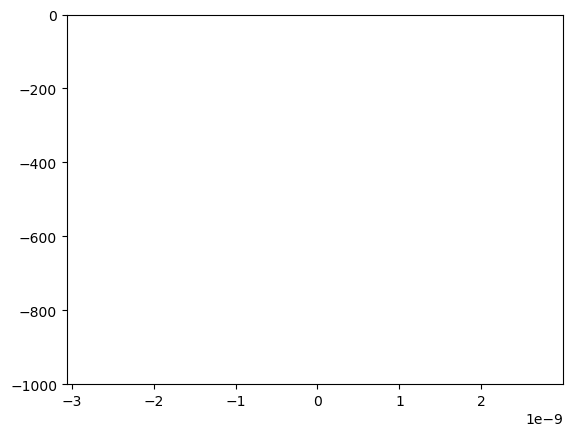

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/api/asynchronous.py:203: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


Year:  2091


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  r

<xarray.DataArray (nz1: 40)> Size: 320B
array([-1.20779453e-09, -1.69291055e-09, -1.95865610e-09, -1.54961735e-09,
        3.44280657e-10,  4.66259762e-09,  5.98776588e-09,  4.19850516e-09,
        2.95465613e-09,  2.22936613e-09,  1.71676856e-09,  9.36563488e-10,
        4.55157441e-10,  2.38351338e-11, -2.67465280e-10, -3.97337931e-10,
       -2.57553077e-10, -6.33874846e-11, -2.16326481e-11, -4.80981710e-11,
       -5.36519494e-11, -3.81278255e-11, -2.85790729e-12,  1.61398696e-11,
        1.67752316e-11,  1.11766251e-11,  3.77304465e-12, -1.47713804e-12,
       -5.37941793e-12, -9.09897575e-12, -1.31715435e-11, -2.03342394e-11,
       -3.49327789e-11, -6.69228826e-11, -1.20742011e-10, -1.90016685e-10,
       -3.39288120e-10, -5.63817854e-10, -7.87982420e-10, -9.69594952e-10])
Coordinates:
  * nz1      (nz1) float64 320B 2.5 7.5 15.0 ... 3.775e+03 4.025e+03 4.275e+03
Attributes: (12/22)
    long_name:    zonal velocity at nodes
    units:        m/s
    description:  zonal velocity 

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distrib

...

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distrib

<xarray.DataArray (nz1: 40)> Size: 320B
array([ 6.75707396e-10,  7.33589734e-10,  3.64168240e-10,  1.57399975e-09,
        3.70528375e-09,  3.38500729e-09,  2.39422090e-09,  2.22026736e-09,
        2.29419890e-09,  2.26653825e-09,  2.21838493e-09,  1.75684884e-09,
        1.12920793e-09,  5.25622886e-10,  7.61008555e-11, -1.85581718e-10,
       -2.48650623e-10, -2.67289457e-10, -2.88049859e-10, -2.41660868e-10,
       -1.30202604e-10, -3.73528274e-11,  5.72069167e-12,  1.43380276e-11,
        6.67303758e-12,  2.24219765e-12, -2.67002202e-12, -9.95624087e-12,
       -1.59746213e-11, -2.25687067e-11, -2.73494221e-11, -2.76601479e-11,
       -3.13251506e-11, -3.55769713e-11, -4.17643498e-11, -7.04397855e-11,
       -1.27959918e-10, -1.32436333e-10, -1.22913411e-10, -9.46633082e-11])
Coordinates:
  * nz1      (nz1) float64 320B 2.5 7.5 15.0 ... 3.775e+03 4.025e+03 4.275e+03
Attributes: (12/22)
    long_name:    zonal velocity at nodes
    units:        m/s
    description:  zonal velocity 

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distrib

<xarray.DataArray (nz1: 40)> Size: 320B
array([-5.62591148e-10, -1.61164231e-10, -6.79611664e-10,  7.81428475e-12,
        3.10310573e-09,  4.49503498e-09,  3.52899239e-09,  2.66584514e-09,
        2.56039983e-09,  2.73343939e-09,  2.92989782e-09,  2.60234944e-09,
        2.19084725e-09,  1.59495268e-09,  9.51840310e-10,  4.03075296e-10,
        8.24753059e-11, -8.24349844e-11, -1.54518196e-10, -1.52971463e-10,
       -9.14052115e-11, -2.86321784e-11,  2.27346257e-12,  1.93909378e-11,
        1.71952384e-11,  1.16183236e-11,  7.31932370e-12,  3.29636308e-12,
       -2.28602081e-12, -8.13657775e-12, -1.73085906e-11, -3.58825369e-11,
       -6.93111760e-11, -7.36213037e-11, -5.92898639e-11, -6.50731070e-11,
       -1.03571148e-10, -8.56538817e-11, -8.57104212e-11, -1.45462625e-10])
Coordinates:
  * nz1      (nz1) float64 320B 2.5 7.5 15.0 ... 3.775e+03 4.025e+03 4.275e+03
Attributes: (12/22)
    long_name:    zonal velocity at nodes
    units:        m/s
    description:  zonal velocity 

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distrib

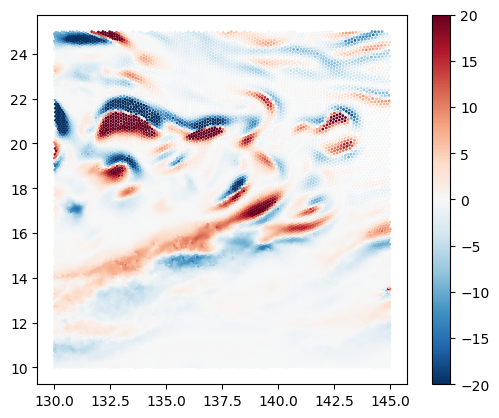

<xarray.DataArray (nz1: 40)> Size: 320B
array([-3.80436370e-09, -3.19577244e-09, -2.78247425e-09, -5.73757936e-10,
        2.60134166e-09,  1.64174335e-09,  7.87318937e-10,  7.80686812e-10,
        1.01269038e-09,  1.19565979e-09,  1.37487387e-09,  1.10863533e-09,
        7.99564962e-10,  3.20250155e-10, -1.82593484e-10, -5.31097340e-10,
       -6.20990629e-10, -5.91874524e-10, -4.95899676e-10, -3.35080347e-10,
       -1.73304701e-10, -8.50153599e-11, -4.21577602e-11, -1.44664230e-11,
       -7.66077547e-12, -5.52254289e-12, -6.14122495e-12, -6.83708514e-12,
       -9.08662307e-12, -1.52128434e-11, -2.68348998e-11, -4.62925451e-11,
       -7.03111088e-11, -8.20225929e-11, -9.37160540e-11, -1.71285409e-10,
       -1.58147885e-10, -1.53030890e-10, -1.39890674e-10, -1.50673480e-10])
Coordinates:
  * nz1      (nz1) float64 320B 2.5 7.5 15.0 ... 3.775e+03 4.025e+03 4.275e+03
Attributes: (12/22)
    long_name:    zonal velocity at nodes
    units:        m/s
    description:  zonal velocity 

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


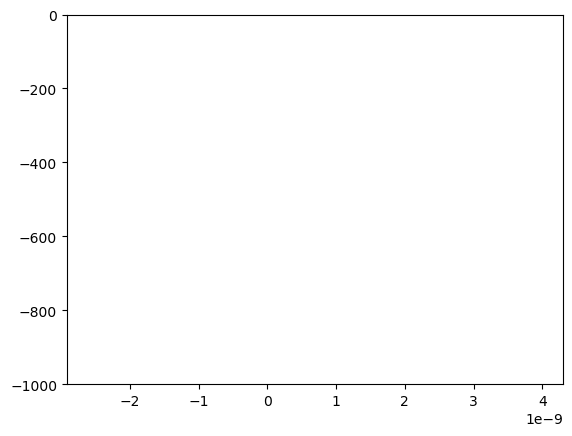

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/api/asynchronous.py:203: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


Year:  2092


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  r

<xarray.DataArray (nz1: 40)> Size: 320B
array([-8.21042288e-09, -7.72736176e-09, -7.03406403e-09, -5.93837511e-09,
       -3.25492865e-09,  1.30294170e-09,  4.07061226e-09,  4.78078022e-09,
        3.40955509e-09,  1.37401832e-09,  9.08193797e-10,  4.87507297e-10,
        7.07394801e-10,  4.75841868e-10, -8.60755038e-12, -3.71864912e-10,
       -3.99319045e-10, -3.73586004e-10, -3.71227497e-10, -3.26178641e-10,
       -2.44294395e-10, -1.38953440e-10, -5.85509323e-11, -1.77759615e-11,
       -4.42570292e-12,  1.05504913e-12,  3.12076917e-12, -1.31888832e-12,
       -1.08601682e-11, -1.99422178e-11, -2.94128242e-11, -3.53630812e-11,
       -4.21455772e-11, -4.44817005e-11, -6.11125104e-11, -1.35920735e-10,
       -3.19937687e-10, -7.38847989e-10, -1.27420140e-09, -1.79938566e-09])
Coordinates:
  * nz1      (nz1) float64 320B 2.5 7.5 15.0 ... 3.775e+03 4.025e+03 4.275e+03
Attributes: (12/22)
    long_name:    zonal velocity at nodes
    units:        m/s
    description:  zonal velocity 

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distrib

...

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distrib

<xarray.DataArray (nz1: 40)> Size: 320B
array([ 1.30266020e-10, -6.50802657e-11, -2.49049633e-10,  1.54990901e-09,
        2.70467476e-09,  1.44214026e-09,  5.70871713e-10,  3.67730029e-10,
        3.49378909e-10,  3.81014713e-10,  7.17580559e-10,  7.23738540e-10,
        9.35692091e-10,  1.16053227e-09,  1.09845109e-09,  6.13389117e-10,
        2.70837472e-10,  5.68524818e-11, -1.28581303e-10, -1.88028936e-10,
       -1.71037354e-10, -1.25806381e-10, -7.93459863e-11, -3.65764754e-11,
       -1.09668825e-11, -5.20489724e-12, -5.86474419e-12, -3.84235157e-12,
       -3.08132247e-12, -4.99005674e-12, -3.97002290e-12, -3.08944694e-12,
       -3.04897004e-12, -8.79066144e-13, -5.80314429e-13, -1.14975849e-11,
       -3.42078619e-11, -5.71068694e-11, -5.26366321e-11, -4.94378689e-11])
Coordinates:
  * nz1      (nz1) float64 320B 2.5 7.5 15.0 ... 3.775e+03 4.025e+03 4.275e+03
Attributes: (12/22)
    long_name:    zonal velocity at nodes
    units:        m/s
    description:  zonal velocity 

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distrib

<xarray.DataArray (nz1: 40)> Size: 320B
array([-1.10792286e-09, -1.47016452e-09, -1.98007000e-09,  1.50180234e-09,
        4.66468805e-09,  2.48237140e-09,  1.12751856e-09,  6.53937454e-10,
        4.41695354e-10,  3.73842983e-10,  5.58444298e-10,  4.72108897e-10,
        5.19450264e-10,  5.14657344e-10,  4.25285316e-10,  1.34904254e-10,
       -2.18543989e-10, -6.48939524e-10, -1.03475129e-09, -1.15845063e-09,
       -9.78140418e-10, -7.22902786e-10, -4.61399350e-10, -2.62056644e-10,
       -1.34751052e-10, -6.89638112e-11, -3.89690179e-11, -2.27046150e-11,
       -1.21693229e-11, -5.24352365e-12, -2.38348614e-12, -1.86401428e-12,
        4.52137410e-13,  2.18893668e-13, -1.94230090e-12, -2.45921423e-11,
       -3.03319812e-11, -5.82318477e-11, -9.33088788e-11, -9.31414597e-11])
Coordinates:
  * nz1      (nz1) float64 320B 2.5 7.5 15.0 ... 3.775e+03 4.025e+03 4.275e+03
Attributes: (12/22)
    long_name:    zonal velocity at nodes
    units:        m/s
    description:  zonal velocity 

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distrib

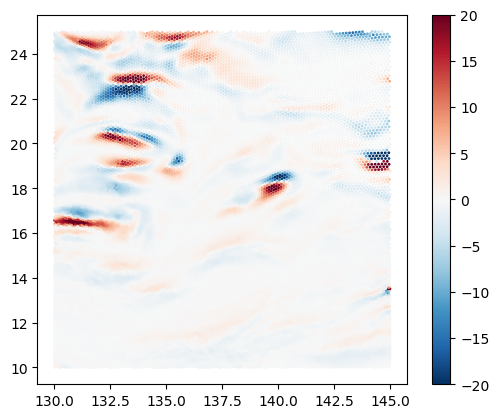

<xarray.DataArray (nz1: 40)> Size: 320B
array([-8.11216597e-10, -1.05826306e-09, -1.24207909e-09,  5.79013078e-10,
        3.69093322e-09,  3.00984613e-09,  1.53451750e-09,  1.03916080e-09,
        9.25595232e-10,  8.97870297e-10,  1.02028812e-09,  8.51461093e-10,
        6.90080082e-10,  3.96332952e-10,  8.14178314e-11, -1.85526374e-10,
       -3.08285761e-10, -3.62599972e-10, -4.34110212e-10, -4.48508117e-10,
       -3.96023629e-10, -3.10819493e-10, -2.52075508e-10, -1.75233324e-10,
       -9.41926448e-11, -4.36988814e-11, -1.88121310e-11, -6.52408768e-12,
       -2.80472165e-12, -3.39812156e-12, -5.28330956e-12, -6.99215148e-12,
       -8.84464388e-12, -1.66570357e-11, -3.06471951e-11, -4.53063176e-11,
       -8.30577414e-11, -1.25904481e-10, -1.60893607e-10, -1.09482065e-10])
Coordinates:
  * nz1      (nz1) float64 320B 2.5 7.5 15.0 ... 3.775e+03 4.025e+03 4.275e+03
Attributes: (12/22)
    long_name:    zonal velocity at nodes
    units:        m/s
    description:  zonal velocity 

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


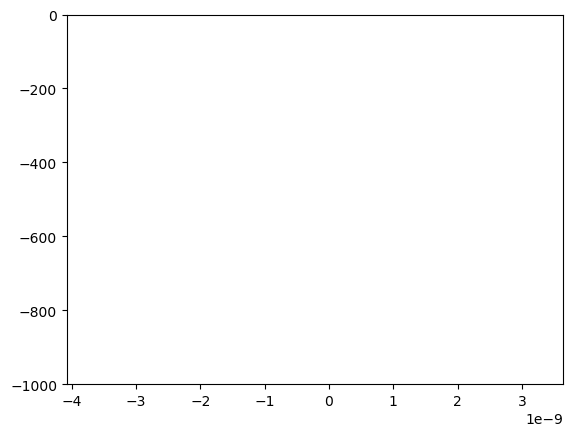

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/api/asynchronous.py:203: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


Year:  2093


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  r

<xarray.DataArray (nz1: 40)> Size: 320B
array([-4.33532074e-09, -4.13859052e-09, -3.47233988e-09, -2.23858640e-09,
       -5.29604480e-10,  1.67088630e-09,  2.21846918e-09,  1.43861906e-09,
        9.78867007e-10,  7.16756089e-10,  8.15921648e-10,  5.63835856e-10,
        5.49581066e-10,  4.94604628e-10,  3.92810288e-10,  2.47201265e-10,
        1.73052983e-10, -6.60595127e-11, -4.80582597e-10, -8.57753592e-10,
       -9.44795774e-10, -7.11490724e-10, -4.53153002e-10, -2.76156142e-10,
       -1.73531143e-10, -1.11263316e-10, -7.30166763e-11, -5.02130193e-11,
       -3.02078789e-11, -1.65057290e-11, -1.04844929e-11, -9.57414020e-12,
       -1.06888924e-11, -2.42353505e-11, -7.40684319e-11, -2.10214067e-10,
       -5.72558525e-10, -1.42612979e-09, -2.19924547e-09, -2.95892557e-09])
Coordinates:
  * nz1      (nz1) float64 320B 2.5 7.5 15.0 ... 3.775e+03 4.025e+03 4.275e+03
Attributes: (12/22)
    long_name:    zonal velocity at nodes
    units:        m/s
    description:  zonal velocity 

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distrib

...

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distrib

<xarray.DataArray (nz1: 40)> Size: 320B
array([-3.12920625e-09, -2.70256530e-09, -2.81210121e-09, -2.05065268e-09,
        6.80010739e-10,  7.23814192e-10,  1.93972366e-10,  2.11519597e-10,
        3.66854874e-10,  4.80133964e-10,  7.23079090e-10,  6.83860881e-10,
        8.22793556e-10,  9.46648730e-10,  1.00206422e-09,  8.10151172e-10,
        4.85249782e-10,  1.73865004e-10, -7.90709729e-11, -1.96237588e-10,
       -2.10563685e-10, -1.67930905e-10, -1.14310884e-10, -6.76789194e-11,
       -3.14616634e-11, -1.09533413e-11,  1.07570893e-12,  5.58585461e-12,
        4.44810458e-12,  1.61077170e-12,  4.77098026e-13,  5.09894130e-13,
        1.48601776e-12,  2.39421344e-12,  3.16225255e-12,  3.49873446e-12,
        4.26229950e-12,  6.09106710e-12,  4.58128639e-12,  2.91802600e-12])
Coordinates:
  * nz1      (nz1) float64 320B 2.5 7.5 15.0 ... 3.775e+03 4.025e+03 4.275e+03
Attributes: (12/22)
    long_name:    zonal velocity at nodes
    units:        m/s
    description:  zonal velocity 

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distrib

<xarray.DataArray (nz1: 40)> Size: 320B
array([-3.53942295e-09, -2.73225743e-09, -1.99095887e-09, -4.33528938e-11,
        7.29486452e-10,  6.21802347e-10,  6.21838395e-10,  8.40830943e-10,
        1.04432440e-09,  1.13916466e-09,  1.30626886e-09,  1.26932050e-09,
        1.35594736e-09,  1.43875563e-09,  1.39988155e-09,  9.97929661e-10,
        5.07955746e-10,  2.08211898e-10,  9.47167541e-11,  7.59957543e-11,
        4.25454238e-11, -6.72582739e-12, -2.04286293e-11, -7.97535832e-12,
        9.33831218e-12,  1.55052314e-11,  8.87667573e-12, -3.67589265e-12,
       -1.33616261e-11, -1.54685986e-11, -1.41791859e-11, -1.97030699e-11,
       -3.06875237e-11, -2.79848829e-11, -2.37260662e-11, -2.86741140e-11,
       -4.53192055e-11, -9.80292778e-11, -2.17921073e-10, -2.15991343e-10])
Coordinates:
  * nz1      (nz1) float64 320B 2.5 7.5 15.0 ... 3.775e+03 4.025e+03 4.275e+03
Attributes: (12/22)
    long_name:    zonal velocity at nodes
    units:        m/s
    description:  zonal velocity 

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distrib

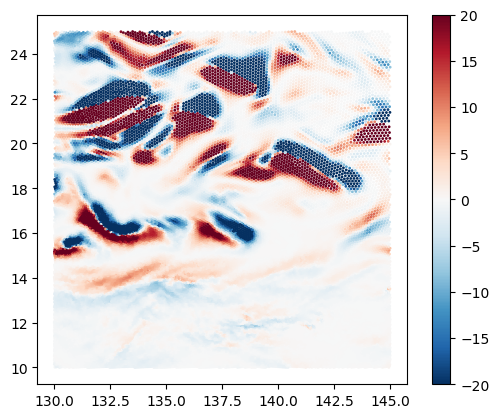

<xarray.DataArray (nz1: 40)> Size: 320B
array([ 4.07559066e-09,  4.34230012e-09,  3.43818673e-09,  1.75222618e-09,
        2.67522416e-09,  3.00111770e-09,  1.72987590e-09,  1.24784330e-09,
        1.05053990e-09,  9.40021692e-10,  8.98286743e-10,  7.29363667e-10,
        5.49645325e-10,  2.85918973e-10, -1.50821543e-12, -2.54455961e-10,
       -3.47799185e-10, -3.23083150e-10, -3.28344109e-10, -4.71042416e-10,
       -6.78144068e-10, -6.56695345e-10, -4.56321023e-10, -2.41247264e-10,
       -9.88642635e-11, -2.91747695e-11, -3.67715821e-12,  2.44659031e-12,
        6.82576157e-13, -2.47162943e-12, -4.65481823e-12, -5.58073159e-12,
       -1.29178699e-11, -9.49924859e-12, -1.79911288e-11, -4.35790292e-11,
       -1.05357826e-10, -2.33560752e-10, -4.05794758e-10, -4.05525931e-10])
Coordinates:
  * nz1      (nz1) float64 320B 2.5 7.5 15.0 ... 3.775e+03 4.025e+03 4.275e+03
Attributes: (12/22)
    long_name:    zonal velocity at nodes
    units:        m/s
    description:  zonal velocity 

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


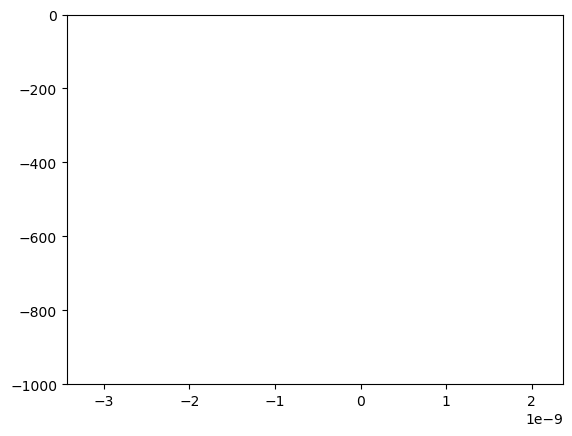

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/api/asynchronous.py:203: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


Year:  2094


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter

<xarray.DataArray (nz1: 40)> Size: 320B
array([-4.69746516e-09, -4.56743760e-09, -4.14337438e-09, -2.26947253e-09,
        1.66052488e-10,  2.70136055e-09,  2.73654983e-09,  1.60916358e-09,
        9.48609974e-10,  6.96609409e-10,  8.69225004e-10,  7.63596621e-10,
        8.73987860e-10,  8.68323015e-10,  7.52345054e-10,  5.89618473e-10,
        4.59934948e-10,  2.69737590e-10,  8.59134918e-11, -4.58161983e-11,
       -1.02696689e-10, -1.02614188e-10, -9.20960457e-11, -7.16811911e-11,
       -5.55126018e-11, -4.60967391e-11, -3.69672311e-11, -3.32035288e-11,
       -3.17511204e-11, -2.71950647e-11, -3.02678272e-11, -3.97371713e-11,
       -5.29745459e-11, -6.62589072e-11, -8.12691921e-11, -1.31386737e-10,
       -2.74526366e-10, -5.87613697e-10, -8.80215696e-10, -1.22032868e-09])
Coordinates:
  * nz1      (nz1) float64 320B 2.5 7.5 15.0 ... 3.775e+03 4.025e+03 4.275e+03
Attributes: (12/22)
    long_name:    zonal velocity at nodes
    units:        m/s
    description:  zonal velocity 

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distrib

...

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distrib

<xarray.DataArray (nz1: 40)> Size: 320B
array([-6.83620149e-10, -9.36990709e-10, -4.88751656e-10,  1.68688677e-09,
        3.43969307e-09,  3.40538095e-09,  2.59347735e-09,  1.67465938e-09,
        1.28316262e-09,  1.05465305e-09,  1.03151186e-09,  4.43834705e-10,
       -2.89391076e-12, -3.11012791e-10, -5.86521679e-10, -7.60042819e-10,
       -7.02006196e-10, -5.45434461e-10, -3.91995408e-10, -2.11735797e-10,
       -6.20663208e-11, -1.63011584e-11, -6.24980107e-12,  4.10347435e-12,
        6.43598851e-12,  5.13735352e-12,  2.39081528e-12, -4.28500139e-12,
       -1.06636174e-11, -1.11523721e-11, -7.59087218e-12, -8.63205086e-12,
       -1.35463351e-11, -1.15011830e-11, -1.62710162e-11, -5.51022176e-11,
       -8.81874755e-11, -1.60638554e-10, -2.65397980e-10, -2.56525622e-10])
Coordinates:
  * nz1      (nz1) float64 320B 2.5 7.5 15.0 ... 3.775e+03 4.025e+03 4.275e+03
Attributes: (12/22)
    long_name:    zonal velocity at nodes
    units:        m/s
    description:  zonal velocity 

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distrib

<xarray.DataArray (nz1: 40)> Size: 320B
array([ 1.28442287e-09,  1.48067987e-09, -5.21682873e-10,  7.91221052e-11,
        4.44334998e-09,  4.62771436e-09,  2.83562323e-09,  1.84170863e-09,
        1.54811283e-09,  1.36196287e-09,  1.26759193e-09,  7.60948374e-10,
        3.53894104e-10, -8.92947157e-12, -3.18898526e-10, -5.58098258e-10,
       -5.60974986e-10, -4.54981046e-10, -3.08664242e-10, -1.70224110e-10,
       -8.81294458e-11, -6.33577720e-11, -4.34616178e-11, -2.26564851e-11,
       -1.24173357e-11, -6.39740507e-12, -1.32883155e-12, -1.93517878e-12,
       -3.29715828e-12, -2.71536476e-12, -8.95910619e-12, -2.88488035e-11,
       -5.96272738e-11, -6.70034178e-11, -7.78828139e-11, -9.26090328e-11,
       -1.27628185e-10, -2.31265485e-10, -2.99780660e-10, -2.10170713e-10])
Coordinates:
  * nz1      (nz1) float64 320B 2.5 7.5 15.0 ... 3.775e+03 4.025e+03 4.275e+03
Attributes: (12/22)
    long_name:    zonal velocity at nodes
    units:        m/s
    description:  zonal velocity 

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distrib

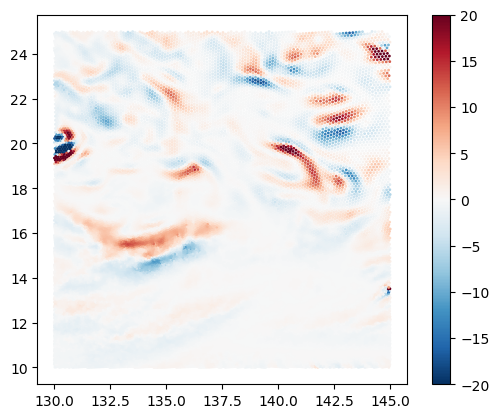

<xarray.DataArray (nz1: 40)> Size: 320B
array([-6.50157498e-10, -6.79173544e-10, -1.12572792e-09,  1.09312233e-09,
        5.66001268e-09,  4.07253507e-09,  1.54503071e-09,  6.97048764e-10,
        7.11680095e-10,  7.91123503e-10,  9.91109530e-10,  6.76151070e-10,
        3.74454987e-10, -1.13418503e-11, -2.98166246e-10, -4.72804917e-10,
       -5.26654078e-10, -4.89862010e-10, -3.86224579e-10, -2.62386020e-10,
       -1.64351472e-10, -1.15765081e-10, -8.32145789e-11, -4.84481792e-11,
       -3.07473604e-11, -2.04393196e-11, -1.21548486e-11, -7.30983415e-12,
       -5.38282204e-12, -4.92918907e-12, -9.80776318e-12, -2.55401908e-11,
       -5.34236808e-11, -6.69746834e-11, -7.95483436e-11, -1.27374513e-10,
       -1.51229483e-10, -3.30363899e-10, -4.57658220e-10, -4.39553273e-10])
Coordinates:
  * nz1      (nz1) float64 320B 2.5 7.5 15.0 ... 3.775e+03 4.025e+03 4.275e+03
Attributes: (12/22)
    long_name:    zonal velocity at nodes
    units:        m/s
    description:  zonal velocity 

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


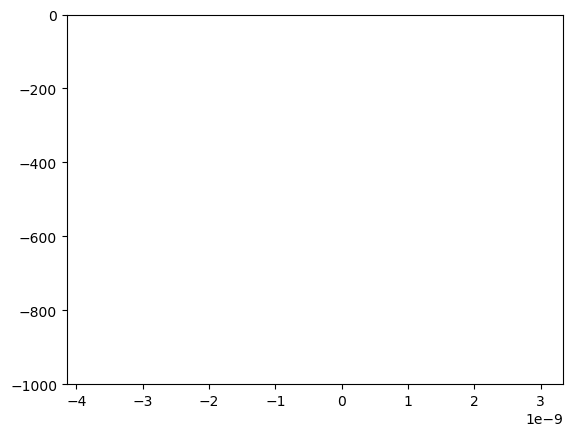

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/api/asynchronous.py:203: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


Year:  2095


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  r

<xarray.DataArray (nz1: 40)> Size: 320B
array([-5.17201240e-09, -5.38541666e-09, -5.43201658e-09, -4.54488437e-09,
       -2.34572829e-09,  1.93167754e-09,  3.44181000e-09,  2.77844966e-09,
        1.63365448e-09,  7.09269082e-10,  6.39631560e-10,  4.48855882e-10,
        4.33718156e-10,  3.42535538e-10,  1.93045327e-10,  1.30974528e-12,
       -1.33519872e-10, -1.89117536e-10, -1.74249840e-10, -1.45665293e-10,
       -1.03941631e-10, -6.34137780e-11, -3.88691088e-11, -2.37407426e-11,
       -1.20104564e-11, -2.22734308e-12,  4.00987923e-12,  4.71901295e-12,
        1.29315814e-12, -7.31275833e-12, -2.74599356e-11, -4.46755156e-11,
       -4.24971119e-11, -2.75850490e-11, -4.77542807e-11, -2.15325414e-10,
       -2.41819735e-10, -3.80733575e-10, -6.25488240e-10, -1.00523835e-09])
Coordinates:
  * nz1      (nz1) float64 320B 2.5 7.5 15.0 ... 3.775e+03 4.025e+03 4.275e+03
Attributes: (12/22)
    long_name:    zonal velocity at nodes
    units:        m/s
    description:  zonal velocity 

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distrib

...

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distrib

<xarray.DataArray (nz1: 40)> Size: 320B
array([-1.95675825e-09, -1.28787398e-09, -4.32660313e-10,  1.52010533e-09,
        1.81429459e-09,  1.24759949e-09,  1.03451381e-09,  1.08628589e-09,
        1.22264549e-09,  1.35751168e-09,  1.59043776e-09,  1.52267719e-09,
        1.39474263e-09,  1.07711358e-09,  6.40435116e-10,  2.21671610e-10,
        4.12624707e-11, -4.61314587e-12, -9.88194185e-12,  5.19758107e-11,
        1.21323967e-10,  1.71044610e-10,  1.97754614e-10,  1.82516253e-10,
        1.45087950e-10,  1.00514083e-10,  6.14219930e-11,  3.16882126e-11,
        1.10232088e-11,  3.70339385e-12,  3.96386200e-12,  5.57975728e-12,
       -6.55331582e-12, -7.84053534e-11, -1.32149503e-10, -1.21087379e-10,
       -1.11686255e-10, -7.68271180e-11, -6.63705127e-11, -1.10814253e-10])
Coordinates:
  * nz1      (nz1) float64 320B 2.5 7.5 15.0 ... 3.775e+03 4.025e+03 4.275e+03
Attributes: (12/22)
    long_name:    zonal velocity at nodes
    units:        m/s
    description:  zonal velocity 

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distrib

<xarray.DataArray (nz1: 40)> Size: 320B
array([-6.59386409e-10, -8.11464864e-10, -6.74505413e-10,  1.12282829e-09,
        1.46653919e-09,  9.47972841e-10,  7.59144552e-10,  8.25165957e-10,
        9.77380344e-10,  1.11472898e-09,  1.24506361e-09,  1.17386308e-09,
        1.04455201e-09,  7.87201733e-10,  4.77941096e-10,  2.67344237e-10,
        1.87533894e-10,  6.65537831e-11, -1.16405998e-11,  2.54137183e-12,
        1.37153436e-10,  1.96196861e-10,  2.22851007e-10,  1.95265003e-10,
        1.45580279e-10,  1.07024405e-10,  7.48768476e-11,  4.79643102e-11,
        2.83473421e-11,  1.49167849e-11,  8.40121161e-12, -2.06646390e-12,
       -2.36895701e-11, -5.14128659e-11, -7.22005961e-11, -1.15117762e-10,
       -1.20695780e-10, -1.48553296e-10, -2.38347623e-10, -2.32104543e-10])
Coordinates:
  * nz1      (nz1) float64 320B 2.5 7.5 15.0 ... 3.775e+03 4.025e+03 4.275e+03
Attributes: (12/22)
    long_name:    zonal velocity at nodes
    units:        m/s
    description:  zonal velocity 

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distrib

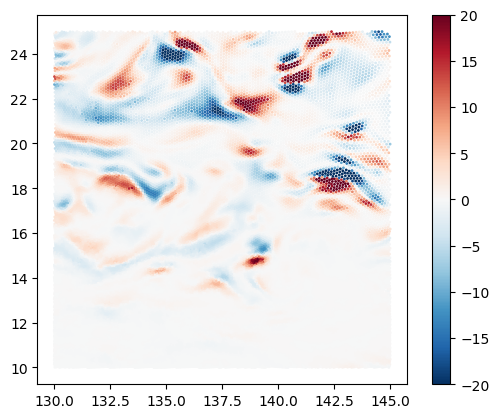

<xarray.DataArray (nz1: 40)> Size: 320B
array([-5.19208128e-10, -6.68716162e-10, -1.45783590e-09, -1.34652930e-09,
        2.73903725e-10,  1.05996541e-10, -2.46066635e-11,  3.61495023e-10,
        7.55180706e-10,  1.01188056e-09,  1.61045333e-09,  1.67832801e-09,
        1.86569279e-09,  1.71498238e-09,  1.11554988e-09,  4.82297001e-10,
        2.92745956e-10,  2.34362315e-10,  1.25093426e-10,  1.43034326e-11,
        8.46536349e-11,  2.07596322e-10,  2.44056643e-10,  2.12627631e-10,
        1.57145709e-10,  1.00836165e-10,  6.56131257e-11,  4.63648322e-11,
        3.32565977e-11,  2.13552224e-11,  1.55626117e-11,  4.55755345e-12,
       -4.45652570e-12, -1.24728631e-11, -2.64586361e-11, -6.57604677e-11,
       -1.45304832e-10, -2.50861285e-10, -4.05201908e-10, -4.53946155e-10])
Coordinates:
  * nz1      (nz1) float64 320B 2.5 7.5 15.0 ... 3.775e+03 4.025e+03 4.275e+03
Attributes: (12/22)
    long_name:    zonal velocity at nodes
    units:        m/s
    description:  zonal velocity 

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


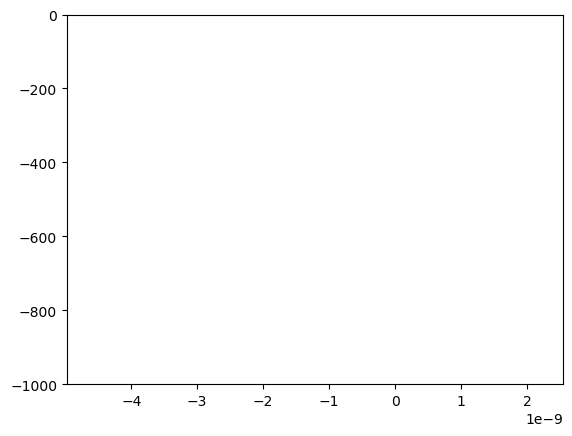

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/api/asynchronous.py:203: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


Year:  2096


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter

<xarray.DataArray (nz1: 40)> Size: 320B
array([-6.80556802e-09, -5.98108005e-09, -4.89081910e-09, -3.15884890e-09,
       -7.78435084e-10,  1.73137668e-09,  2.37624040e-09,  2.20151735e-09,
        1.52094498e-09,  9.05897299e-10,  9.65832709e-10,  5.75337732e-10,
        5.94225058e-10,  5.26304505e-10,  4.19306965e-10,  2.26924507e-10,
        6.97297264e-11, -1.26099060e-10, -2.78180967e-10, -3.02377055e-10,
       -2.53405509e-10, -1.65858369e-10, -7.26559526e-11, -1.21700110e-11,
        9.15073024e-12,  1.06661511e-11,  7.08471693e-12,  4.15769627e-12,
       -1.60774067e-12, -6.29099141e-12, -1.07549049e-11, -2.30133675e-11,
       -4.40380790e-11, -8.08034992e-11, -1.45846588e-10, -3.42784596e-10,
       -8.17987752e-10, -1.48143824e-09, -2.12417053e-09, -2.57199055e-09])
Coordinates:
  * nz1      (nz1) float64 320B 2.5 7.5 15.0 ... 3.775e+03 4.025e+03 4.275e+03
Attributes: (12/22)
    long_name:    zonal velocity at nodes
    units:        m/s
    description:  zonal velocity 

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter

...

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distrib

<xarray.DataArray (nz1: 40)> Size: 320B
array([-5.69276879e-10,  2.08650809e-10,  8.24776483e-10,  2.83408912e-09,
        4.45597992e-09,  3.92675833e-09,  3.54911434e-09,  3.36166952e-09,
        3.18370763e-09,  2.90891245e-09,  2.77838128e-09,  2.39033721e-09,
        1.95726059e-09,  1.61545162e-09,  1.20032805e-09,  8.00259534e-10,
        5.38142529e-10,  3.95563109e-10,  2.92972732e-10,  2.32419119e-10,
        1.98916938e-10,  1.58045126e-10,  1.20134144e-10,  8.72351661e-11,
        6.14780138e-11,  4.43587944e-11,  2.88209671e-11,  9.27985987e-12,
        6.85601414e-12,  2.14139836e-13, -4.21878716e-12, -1.26182123e-11,
       -2.49760154e-11, -5.71954063e-11, -1.08941398e-10, -1.72536557e-10,
       -2.71276918e-10, -3.74311768e-10, -4.45208690e-10, -4.03020457e-10])
Coordinates:
  * nz1      (nz1) float64 320B 2.5 7.5 15.0 ... 3.775e+03 4.025e+03 4.275e+03
Attributes: (12/22)
    long_name:    zonal velocity at nodes
    units:        m/s
    description:  zonal velocity 

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distrib

<xarray.DataArray (nz1: 40)> Size: 320B
array([ 6.19573366e-09,  5.74524873e-09,  3.99015940e-09,  6.39102748e-09,
        1.07969341e-08,  8.92073210e-09,  6.15511520e-09,  5.08904529e-09,
        4.42959130e-09,  3.95485148e-09,  3.33354917e-09,  2.48571269e-09,
        2.20488179e-09,  1.81132691e-09,  1.17357412e-09,  6.34094695e-10,
        5.08270616e-10,  4.74276435e-10,  3.53177553e-10,  2.82719977e-10,
        3.15848496e-10,  3.28442178e-10,  2.60159512e-10,  1.94034036e-10,
        1.46277354e-10,  1.00480754e-10,  6.67299170e-11,  4.04418246e-11,
        2.08526011e-11,  4.94947610e-12, -7.11102110e-12, -1.49334019e-11,
       -2.61752333e-11, -3.81857879e-11, -5.02635776e-11, -6.50151322e-11,
       -1.12591342e-10, -1.91692125e-10, -2.24168470e-10, -2.05119571e-10])
Coordinates:
  * nz1      (nz1) float64 320B 2.5 7.5 15.0 ... 3.775e+03 4.025e+03 4.275e+03
Attributes: (12/22)
    long_name:    zonal velocity at nodes
    units:        m/s
    description:  zonal velocity 

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distrib

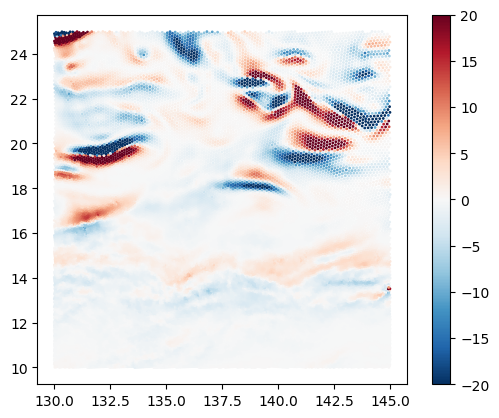

<xarray.DataArray (nz1: 40)> Size: 320B
array([-5.07409824e-09, -4.32259413e-09, -2.92379376e-09,  5.92436996e-10,
        3.65760952e-09,  3.66143348e-09,  3.04036220e-09,  2.61284302e-09,
        2.56149775e-09,  2.54270779e-09,  2.85642209e-09,  2.09752562e-09,
        1.61677552e-09,  1.01846742e-09,  5.42393298e-10,  2.54247245e-10,
        3.22082988e-10,  2.91858499e-10,  1.43714140e-10,  8.63268345e-11,
        7.92456498e-11,  9.28310736e-11,  8.66891888e-11,  7.19949091e-11,
        5.34642298e-11,  2.89595884e-11,  1.15341852e-11,  4.00471406e-12,
        4.63757224e-12,  5.31061737e-12,  2.13030668e-12, -7.39598334e-12,
       -2.19058387e-11, -4.35405739e-11, -5.73137450e-11, -9.12614941e-11,
       -1.18833034e-10, -1.48520992e-10, -1.38533855e-10, -1.03876457e-10])
Coordinates:
  * nz1      (nz1) float64 320B 2.5 7.5 15.0 ... 3.775e+03 4.025e+03 4.275e+03
Attributes: (12/22)
    long_name:    zonal velocity at nodes
    units:        m/s
    description:  zonal velocity 

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


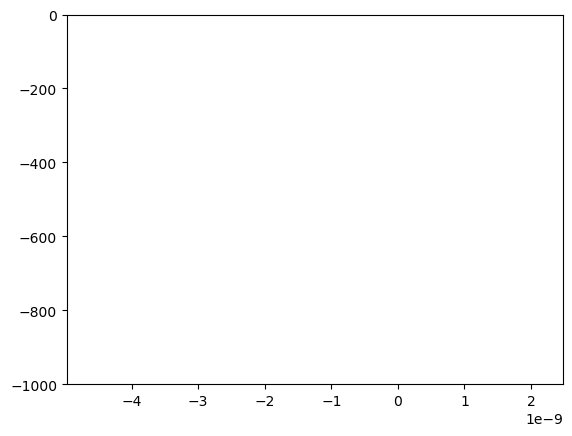

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/zarr/api/asynchronous.py:203: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


Year:  2097


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter

<xarray.DataArray (nz1: 40)> Size: 320B
array([-4.07818593e-09, -4.04710896e-09, -3.92036188e-09, -3.55606640e-09,
       -2.02089289e-09,  1.50858211e-09,  2.59126743e-09,  2.56747149e-09,
        1.69604838e-09,  8.86833960e-10,  9.32618627e-10,  5.64744138e-10,
        3.91742007e-10,  1.45717231e-10, -3.07378399e-11, -6.83789239e-11,
        5.76594756e-11,  3.16034174e-11, -1.87547753e-10, -3.91631207e-10,
       -3.98809015e-10, -2.58266948e-10, -1.24445503e-10, -4.04523450e-11,
       -7.48281369e-12, -1.48310958e-12, -4.36175983e-12, -8.89480194e-12,
       -1.25508055e-11, -1.31571631e-11, -1.57371041e-11, -2.84325165e-11,
       -4.96221551e-11, -7.83798393e-11, -1.58151957e-10, -2.81106166e-10,
       -5.91668788e-10, -9.30163397e-10, -1.20681087e-09, -1.51173145e-09])
Coordinates:
  * nz1      (nz1) float64 320B 2.5 7.5 15.0 ... 3.775e+03 4.025e+03 4.275e+03
Attributes: (12/22)
    long_name:    zonal velocity at nodes
    units:        m/s
    description:  zonal velocity 

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distrib

...

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distrib

<xarray.DataArray (nz1: 40)> Size: 320B
array([-5.75163761e-10, -6.51183677e-10, -7.54550266e-10,  7.56097625e-10,
        1.29803858e-09,  8.89207871e-10,  7.39319748e-10,  8.44072446e-10,
        9.62873329e-10,  9.78331848e-10,  9.75173259e-10,  7.71341062e-10,
        6.18912249e-10,  4.96441998e-10,  3.84618264e-10,  2.76989006e-10,
        2.11154760e-10,  8.68392328e-11, -8.63387202e-11, -2.06120550e-10,
       -1.86445219e-10, -9.99022180e-11, -2.88609945e-11,  1.72538908e-11,
        2.23574260e-11,  7.02807581e-12, -5.16203420e-12, -1.35717941e-11,
       -1.78160685e-11, -2.08037284e-11, -2.18149534e-11, -1.64971317e-11,
       -9.32210304e-12, -2.24523140e-11, -2.79512938e-11, -3.44892733e-11,
       -5.71494854e-11, -6.92632359e-11, -7.75610270e-11, -9.63099701e-11])
Coordinates:
  * nz1      (nz1) float64 320B 2.5 7.5 15.0 ... 3.775e+03 4.025e+03 4.275e+03
Attributes: (12/22)
    long_name:    zonal velocity at nodes
    units:        m/s
    description:  zonal velocity 

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distrib

<xarray.DataArray (nz1: 40)> Size: 320B
array([-9.89483788e-10, -8.32781882e-10, -1.30955453e-09, -2.29606804e-10,
        1.58402628e-09,  1.31715371e-09,  4.66766886e-10,  2.39143069e-10,
        3.57901069e-10,  5.02164054e-10,  6.44343231e-10,  6.08231924e-10,
        6.56203204e-10,  6.95916246e-10,  6.92282369e-10,  6.00711453e-10,
        3.51988109e-10, -2.09543998e-10, -8.22382721e-10, -1.20295726e-09,
       -1.18925165e-09, -8.13030718e-10, -4.37794233e-10, -1.81965005e-10,
       -5.52339357e-11, -1.41511901e-11, -7.91892712e-12, -1.07839183e-11,
       -1.33703639e-11, -1.43553206e-11, -1.37976899e-11, -1.02808727e-11,
       -5.91460796e-12, -7.70039092e-12, -2.04998648e-11, -5.07175931e-11,
       -1.03798928e-10, -1.75410723e-10, -1.92624205e-10, -1.45265663e-10])
Coordinates:
  * nz1      (nz1) float64 320B 2.5 7.5 15.0 ... 3.775e+03 4.025e+03 4.275e+03
Attributes: (12/22)
    long_name:    zonal velocity at nodes
    units:        m/s
    description:  zonal velocity 

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:1002: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  if   (mon is not None): sel_mon = np.in1d( data['time.month'], mon)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/distrib

In [ ]:
ystart = 2090

JFMJAS = np.concatenate((np.arange(1,4, dtype=int),
                         np.arange(7,10, dtype=int))
                       )
reg = "WestPac"

# for yy in np.arange(ystart,2011,1, dtype=int):
for yy in range(ystart,2101):
    
    h_path = op.join(ddir,'N%02d/outdata/fesom/MLD2.fesom.%4d.nc'
                      % (NXX,yy))
    maskS = xr.open_zarr(op.join(sdir,"salt-mask_%4d.zarr" 
                                 % (yy))
                        ).mask
    maskS.coords["nod2"] = ("nod2",np.arange(len(diag.nod2)))
    
    months = JFMJAS
    
    for mm in months:
        
        tu = xr.open_zarr(op.join(sdir,"ke_adv/N%2d/Tu_%4d-%02d.zarr" 
                                       % (NXX,yy,mm))
                         ).reset_coords(drop=True)
        
        mld = tpv.load_data_fesom2(mesh, h_path, do_filename=True,
                                  vname="MLD2", do_info=False,
                                  year=yy, mon=[mm]
                                 ).chunk({'nod2':100000})
        
        tu.coords["nod2"] = ("nod2",np.arange(len(mld.nod2)))
        tu.coords["lon"] = ("nod2", mld.lon.data)
        tu.coords["lat"] = ("nod2", mld.lat.data)
        if mm == 1:
            area.coords["lon"] = ("nod2", mld.lon.data)
            area.coords["lat"] = ("nod2", mld.lat.data)
            mask_reg = maskS.isel(time=mm-1).reset_coords(drop=True).load()
            tu_reg = (tu.Tu*area.reset_coords(drop=True)
                     ).where((~mask_reg) & (depth < -2e2), 
                             drop=True
                            ).load()
            tu_reg = tu_reg.where((tu_reg.lat>regions[reg]["so"]) 
                                  & (tu_reg.lat<regions[reg]["no"])
                                  & (tu_reg.lon>regions[reg]["we"]) 
                                  & (tu_reg.lon<regions[reg]["ea"]), 
                                  drop=True
                                 )
            area_reg = area.where((~mask_reg) & (depth < -2e2), 
                                  drop=True
                                 ).load()
            area_reg = area_reg.where((area_reg.lat>regions[reg]["so"]) 
                                      & (area_reg.lat<regions[reg]["no"])
                                      & (area_reg.lon>regions[reg]["we"]) 
                                      & (area_reg.lon<regions[reg]["ea"]), 
                                      drop=True
                                     ).reset_coords(drop=True)
            tu_reg = (tu_reg.sum("nod2",skipna=True)
                      / area_reg.sum("nod2",skipna=True)
                     )
            print(tu_reg)
        else:
            tmp_reg = (tu.Tu*area.reset_coords(drop=True)
                      ).where((~mask_reg) & (depth < -2e2), 
                              drop=True
                             ).load()
            tmp_reg = tmp_reg.where((tmp_reg.lat>regions[reg]["so"]) 
                                    & (tmp_reg.lat<regions[reg]["no"])
                                    & (tmp_reg.lon>regions[reg]["we"]) 
                                    & (tmp_reg.lon<regions[reg]["ea"]),
                                    drop=True
                                   )
            if mm == 9:
                fig, ax = plt.subplots()
                im = ax.scatter(tmp_reg.lon, tmp_reg.lat, c=tmp_reg.isel(nz1=1),
                                s=1, cmap="RdBu_r", vmin=-2e1, vmax=2e1,
                                rasterized=True)
                ax.set_aspect("equal")
                fig.colorbar(im)
                plt.show()
            # area_gs = area.where((~maskS.isel(time=mm-1).reset_coords(drop=True))
            #                      & (diag.zbar_n_bottom < -2e2),
            #                      drop=True
            #                     )
            # area_gs = area_gs.where((area.lat>31) & (area.lat<45)
            #                         & (area.lon>-80) & (area.lon<-60),
            #                         drop=True
            #                        ).reset_coords(drop=True)
            tmp_reg = (tmp_reg.sum("nod2",skipna=True)
                       / area_reg.sum("nod2",skipna=True)
                      )
            print(tmp_reg)
            tu_reg = xr.concat([tu_reg, tmp_reg
                               ], "time")

            del tmp_reg
        mld.close()
        print("Month: ", mm)
    
    tu_reg.coords["time"] = ("time",JFMJAS)
    
    fig, ax = plt.subplots()
    ax.plot(tu_reg.isel(time=slice(None,3)).mean(["time"]), 
            tu_reg.nz1)
    # ax.set_xlim([ppdwp_gs.min(skipna=True).data,
    #              ppdwp_gs.max(skipna=True).data])
    ax.set_ylim([-1e3,0])
    plt.show()
    
    dsave = tu_reg.to_dataset(name="tu")
    dsave.reset_coords(drop=True).to_zarr(wdir+"ke_adv/N%2d/" % NXX +reg+"_%4d.zarr" % yy,
                                          mode="w")
    dsave.close(), tu.close(), maskS.close()
    del tu_reg
    print("Year: ", yy)